Model           | Acc    | Prec   | Rec    | F1     | Time(s) 
Model: Perceptron, accuracy: 0.825, F1: 0.8458149779735683, recall: 0.96, Precision: 0.7559055118110236, Duration: 0.006172895431518555.


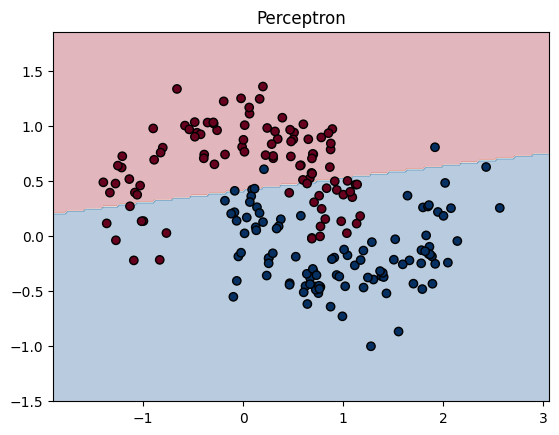

Model: MLP(2-4-1), accuracy: 0.86, F1: 0.86, recall: 0.86, Precision: 0.86, Duration: 0.287243127822876.


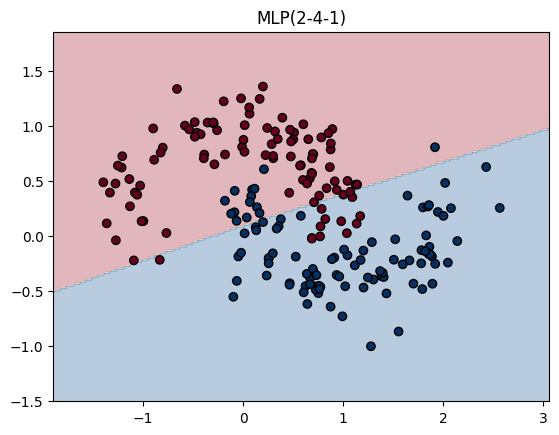

Model: MLP(2-16-8-1), accuracy: 0.985, F1: 0.9847715736040609, recall: 0.97, Precision: 1.0, Duration: 0.5389454364776611.


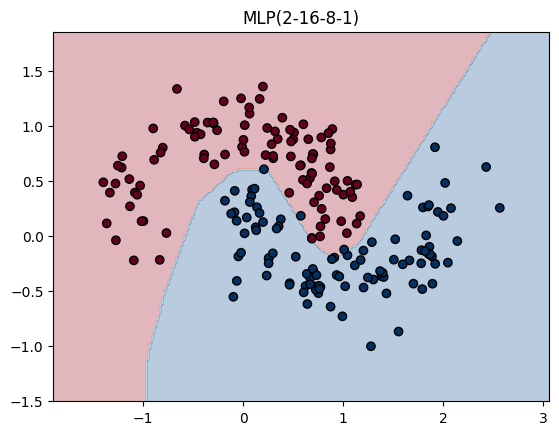

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score,precision_score, recall_score

models={
    "Perceptron": Perceptron(max_iter=1000),
    "MLP(2-4-1)": MLPClassifier(hidden_layer_sizes=(4,), random_state=42, max_iter=2000),
    "MLP(2-16-8-1)": MLPClassifier(hidden_layer_sizes=(16,8), random_state=42, max_iter=2000),
   
}
def plot(clf, X, y,title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdBu')
    plt.title(title)
    plt.show()

X, y=make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train,  X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

print(f"{'Model':<15} | {'Acc':<6} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'Time(s)':<8}")
print("="*65)
for name, clf in models.items():
    start_time=time.time()
    clf.fit(X_train,y_train)
    end_time=time.time()

    y_pred=clf.predict(X_test)

    acc=accuracy_score(y_test, y_pred)
    f1=f1_score(y_test,y_pred)
    re=recall_score(y_test, y_pred)
    pre=precision_score(y_test, y_pred)
    duration=end_time-start_time

    print(f"Model: {name}, accuracy: {acc}, F1: {f1}, recall: {re}, Precision: {pre}, Duration: {duration}.")
    plot(clf, X_test,y_test,name)